In [ ]:
!pip install -q openai-whisper scenedetect[opencv] transformers torch torchvision moviepy pytubefix ipython accelerate scikit-learn matplotlib easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.7/134.7 kB 15.3 MB/s eta 0:00:00


In [ ]:
# Install required libraries
!pip install -q openai-whisper scenedetect[opencv] transformers torch torchvision sentence-transformers faiss-cpu insightface onnxruntime spacy moviepy
!python -m spacy download en_core_web_sm

import os
import gc
import json
import numpy as np
import cv2
import torch
import whisper
import faiss
import spacy
import logging
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scenedetect import open_video, SceneManager, ContentDetector
from transformers import CLIPVisionModelWithProjection, CLIPProcessor, CLIPTextModelWithProjection
from sentence_transformers import SentenceTransformer
from insightface.app import FaceAnalysis
from IPython.display import Image as IPImage, display

logging.disable(logging.WARNING)

# Initialize Global Models
nlp = spacy.load("en_core_web_sm")
text_embedder = SentenceTransformer('all-MiniLM-L6-v2')

# In-memory DBs
shots_db = []
face_db = {} # Maps Name -> Averaged ArcFace Embedding (512d)

print("Setup complete. Ready to process video.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Setup complete. Ready to process video.


In [ ]:
def extract_shots_and_keyframes(video_path, threshold=27.0):
    video = open_video(video_path)
    scene_manager = SceneManager()
    scene_manager.add_detector(ContentDetector(threshold=threshold))
    scene_manager.detect_scenes(video)
    scenes = scene_manager.get_scene_list()

    cap = cv2.VideoCapture(video_path)
    keyframes = []

    for i, (start, end) in enumerate(scenes):
        mid_time = (start.get_seconds() + end.get_seconds()) / 2
        cap.set(cv2.CAP_PROP_POS_MSEC, mid_time * 1000)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            path = f"keyframe_{i}.jpg"
            cv2.imwrite(path, frame)
            keyframes.append({
                "shot_id": i,
                "start_time": start.get_seconds(),
                "end_time": end.get_seconds(),
                "keyframe_path": path,
                "frame_rgb": frame_rgb
            })
    cap.release()
    print(f"Extracted {len(keyframes)} shots.")
    return keyframes

def get_visual_embeddings_and_cluster(keyframes, n_clusters=10):
    from sklearn.cluster import MiniBatchKMeans
    model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    images = [kf['frame_rgb'] for kf in keyframes]
    inputs = processor(images=images, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**inputs)
        embeddings = outputs.image_embeds
    embeddings = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)

    for i, kf in enumerate(keyframes):
        kf['visual_embedding'] = embeddings[i].detach().cpu().numpy().astype('float32')

    del model, processor, inputs, outputs
    gc.collect(); torch.cuda.empty_cache()

    # Clustering for Search-Time Expansion ONLY
    emb_matrix = np.array([kf['visual_embedding'] for kf in keyframes])
    actual_clusters = min(n_clusters, len(keyframes) // 2) if len(keyframes) > 2 else 1
    if actual_clusters > 0:
        kmeans = MiniBatchKMeans(n_clusters=actual_clusters, random_state=42, n_init=3)
        clusters = kmeans.fit_predict(emb_matrix)
        for i, kf in enumerate(keyframes):
            kf['cluster_id'] = int(clusters[i])
        print(f"Grouped shots into {actual_clusters} visual clusters.")
    else:
        for kf in keyframes: kf['cluster_id'] = 0

# Run Tier 0
video_file = "drive/MyDrive/tempo/input_video.mp4" # Ensure this path is correct
shots_db = extract_shots_and_keyframes(video_file)
get_visual_embeddings_and_cluster(shots_db, n_clusters=8)

Extracted 176 shots.


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Grouped shots into 8 visual clusters.


In [ ]:
def transcribe_and_embed_text(video_path, shots):
    # 1. Transcribe
    model = whisper.load_model("small")
    result = model.transcribe(video_path, task="translate")
    print(f"Transcribed video. Language: {result['language']}")
    del model; gc.collect(); torch.cuda.empty_cache()

    # 2. Map to shots and extract clean entities via spaCy
    for shot in shots:
        shot_text = []
        for seg in result['segments']:
            if seg['start'] <= shot['end_time'] and seg['end'] >= shot['start_time']:
                shot_text.append(seg['text'])
        shot['transcript'] = " ".join(shot_text).strip()

        # Clean NER using spaCy (Fixes the "##kita" issue)
        if shot['transcript']:
            doc = nlp(shot['transcript'])
            shot['entities'] = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
        else:
            shot['entities'] = []

    # 3. Generate Text Embeddings
    text_corpus = [shot['transcript'] if shot['transcript'] else "no speech" for shot in shots]
    text_embeddings = text_embedder.encode(text_corpus, convert_to_numpy=True).astype('float32')

    for i, shot in enumerate(shots):
        shot['text_embedding'] = text_embeddings[i]

    print("Text mapping, spaCy NER, and MiniLM embeddings complete.")

transcribe_and_embed_text(video_file, shots_db)

100%|███████████████████████████████████████| 461M/461M [00:07<00:00, 67.1MiB/s]


Transcribed video. Language: en
Text mapping, spaCy NER, and MiniLM embeddings complete.


In [ ]:
def process_faces_and_weak_supervision(shots):
    app = FaceAnalysis(name='buffalo_l')
    app.prepare(ctx_id=0, det_size=(640, 640))

    # Temporary storage: Name -> list of embeddings
    temp_face_map = {}

    for shot in shots:
        img = cv2.imread(shot['keyframe_path'])
        faces = app.get(img)

        shot['faces'] = faces # Save for debug visualization

        if not shot['entities'] or len(faces) == 0:
            continue

        # Weak Supervision: Assign NER entities to the LARGEST face in the frame
        faces_sorted = sorted(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]), reverse=True)
        largest_face = faces_sorted[0]

        for name in shot['entities']:
            if name not in temp_face_map:
                temp_face_map[name] = []
            temp_face_map[name].append(largest_face.normed_embedding)

    # Average embeddings for each person
    for name, embeds in temp_face_map.items():
        avg_embed = np.mean(embeds, axis=0)
        avg_embed = avg_embed / np.linalg.norm(avg_embed)
        face_db[name] = avg_embed.astype('float32')

    print(f"Face extraction complete. Recognized persons: {list(face_db.keys())}")

process_faces_and_weak_supervision(shots_db)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 80665.54KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Face extract

In [ ]:
# Initialize FAISS Indices
dim_visual = 512
dim_text = 384
dim_face = 512

visual_index = faiss.IndexFlatIP(dim_visual)
text_index = faiss.IndexFlatIP(dim_text)
face_index = faiss.IndexFlatIP(dim_face)

# Add all shot data to FAISS
for shot in shots_db:
    visual_index.add(np.array([shot['visual_embedding']]))
    text_index.add(np.array([shot['text_embedding']]))
    # Note: We don't add individual faces to a global shot index,
    # we search face DB directly against face_db vectors mapped from names.

print(f"FAISS indices built. {visual_index.ntotal} visual vectors, {text_index.ntotal} text vectors.")

FAISS indices built. 176 visual vectors, 176 text vectors.


In [ ]:
def search_tempo_cascade(query, top_k=3, candidate_pool_size=50):
    print(f"\n--- PARSING QUERY: '{query}' ---")
    doc = nlp(query)
    names = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    # We pass the entire query to CLIP because CLIP understands natural language visuals
    # But we pass only non-person concepts to MiniLM for transcript matching
    concepts = " ".join([token.text for token in doc if not token.ent_type_ == "PERSON"])

    print(f"Detected Names: {names} | Concepts for Text: '{concepts}'")

    # --- STAGE 1: VISUAL GATEKEEPER (CLIP) ---
    print("\n[Stage 1] Running Visual Search (CLIP)...")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_text_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = clip_text_model(**inputs)
        query_visual_emb = outputs.text_embeds
    query_visual_emb = (query_visual_emb / query_visual_emb.norm(p=2, dim=-1, keepdim=True)).detach().cpu().numpy().astype('float32')
    del clip_processor, clip_text_model; gc.collect(); torch.cuda.empty_cache()

    # Get top 50 visual candidates
    D_v, I_v = visual_index.search(query_visual_emb, candidate_pool_size)

    candidate_shots = []
    for rank, idx in enumerate(I_v[0]):
        candidate_shots.append({
            "shot_id": int(idx),
            "visual_rank": rank,
            "visual_score": D_v[0][rank]
        })
    print(f"Found {len(candidate_shots)} visual candidates. (Top score: {D_v[0][0]:.3f})")

    # --- STAGE 2: FACE FILTER/BOOST ---
    if names:
        target_name = names[0]
        if target_name in face_db:
            print(f"\n[Stage 2] Running Face Filter for: {target_name}")
            face_emb = face_db[target_name]
            filtered_candidates = []

            for cand in candidate_shots:
                shot = shots_db[cand['shot_id']]
                has_face = False
                for face in shot['faces']:
                    sim = np.dot(face_emb, face.normed_embedding)
                    if sim > 0.5: # Face match threshold
                        has_face = True
                        break

                if has_face:
                    cand['face_match'] = True
                    filtered_candidates.append(cand)
                else:
                    cand['face_match'] = False

            # If we found faces, restrict our pool ONLY to shots with the face
            if len(filtered_candidates) > 0:
                print(f"Filtered down to {len(filtered_candidates)} shots containing {target_name}'s face.")
                candidate_shots = filtered_candidates
            else:
                print(f"Warning: {target_name}'s face not found in visual candidates. Retaining visual candidates.")
        else:
            print(f"\nWarning: '{target_name}' not in Face DB. Skipping face filter.")

    # --- STAGE 3: TEXT RE-RANKING (MiniLM) ---
    print("\n[Stage 3] Running Text Re-Ranking (MiniLM) on candidates...")
    query_text_emb = text_embedder.encode([concepts], convert_to_numpy=True).astype('float32')

    # We will calculate a final score heavily favoring Visual Rank, using Text for tie-breaking
    final_scores = []
    for cand in candidate_shots:
        shot = shots_db[cand['shot_id']]
        text_sim = np.dot(query_text_emb[0], shot['text_embedding'])

        # Scoring formula:
        # - Visual Score is normalized (0 to 1)
        # - Text Score is normalized (0 to 1)
        # - Weights: 70% Visual, 30% Text. Face match gets a flat 0.5 boost.

        v_score_norm = (cand['visual_score'] + 1) / 2 # CLIP scores range from -1 to 1
        t_score_norm = (text_sim + 1) / 2             # MiniLM scores range from -1 to 1

        fused_score = (0.7 * v_score_norm) + (0.3 * t_score_norm)

        if cand.get('face_match'):
            fused_score += 0.5 # Hard boost

        final_scores.append({
            "shot_id": cand['shot_id'],
            "fused_score": fused_score,
            "visual_score": cand['visual_score'],
            "text_score": text_sim,
            "face_match": cand.get('face_match', False)
        })

    # Sort by final fused score
    final_scores.sort(key=lambda x: x['fused_score'], reverse=True)
    top_results = final_scores[:top_k]

    # --- OUTPUT & DEBUG ---
    print("\n--- FINAL RESULTS ---")
    for res in top_results:
        shot = shots_db[res['shot_id']]
        print(f"Shot {res['shot_id']} | Fused: {res['fused_score']:.3f} | Vis: {res['visual_score']:.3f} | Txt: {res['text_score']:.3f} | Face: {res['face_match']}")
        print(f"Time: {shot['start_time']:.1f}s - {shot['end_time']:.1f}s")
        print(f"Transcript: {shot['transcript'][:100]}...")
        display(IPImage(filename=shot['keyframe_path'], width=400))
        print("-" * 50)

    # --- CLUSTER EXPANSION ---
    top_shot_id = top_results[0]['shot_id']
    top_shot = shots_db[top_shot_id]
    print(f"\n--- CLUSTER EXPANSION (Cluster {top_shot['cluster_id']}) ---")
    cluster_shots = [s for s in shots_db if s['cluster_id'] == top_shot['cluster_id'] and s['shot_id'] != top_shot_id]

    if cluster_shots:
        print(f"Found {len(cluster_shots)} more shots like this visually:")
        fig, axes = plt.subplots(1, min(3, len(cluster_shots)), figsize=(15, 5))
        if min(3, len(cluster_shots)) == 1: axes = [axes]
        for i, shot in enumerate(cluster_shots[:3]):
            axes[i].imshow(Image.open(shot['keyframe_path']))
            axes[i].set_title(f"Shot {shot['shot_id']}\nTime: {shot['start_time']:.1f}s")
            axes[i].axis('off')
        plt.show()


--- FACE MAPPING DEBUG ---
Name: 'Lewis' mapped at Shot 43 (Time: 129.1s)
Whisper context: This is Lewis by the way.  If you don't know who Lewis is, then you're missing out.  Lewis and I met during study abroad two years ago in Akitam.


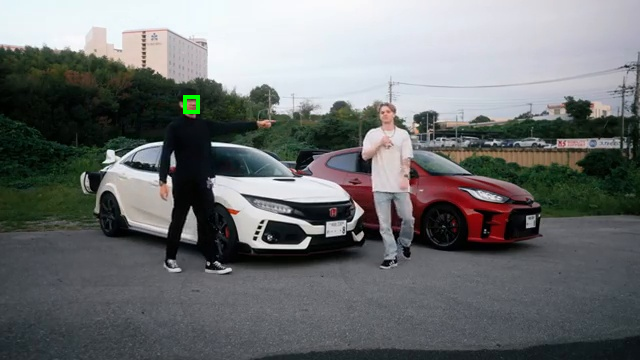

Name: 'Zee' mapped at Shot 143 (Time: 409.5s)
Whisper context: Look at this man.  Look at this man.  Zee!  Our favorite sitcom character is here.


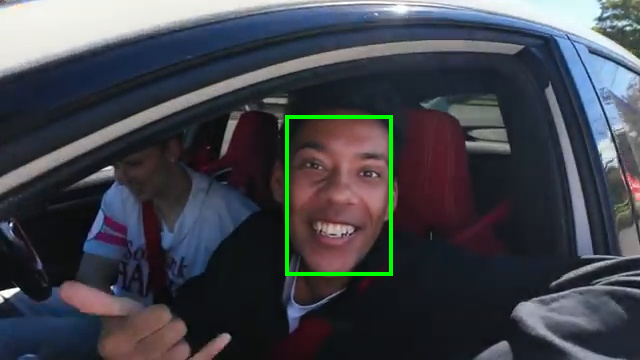

Name: 'Collins' mapped at Shot 167 (Time: 470.0s)
Whisper context: We also cooked in like...  It was like...  Collins.  Collins place.  I didn't...  In my place, to remember that night  when I was like making the energy drink soup.  Oh, that's disgusting.  Did you even finish it?  You didn't even finish it.  Because I used Yoshi's pots and pans.  I didn't even want it to make chicken soup.  So it got super mad at me because I used his pots.  Because it didn't even place to make chicken soup.  So I had to drain it like right there.  Good memories.


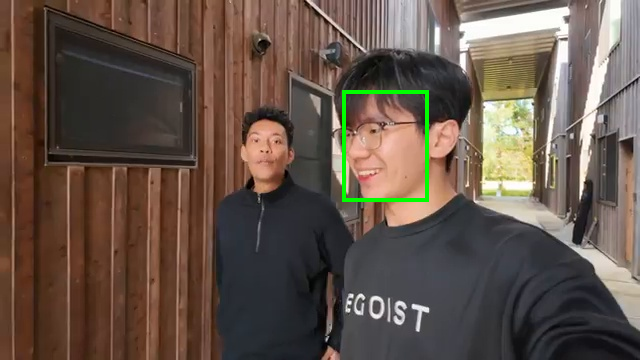

--- SEARCH DEBUG: 'foggy scenery' ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Shot   | CLIP (Vis) | MiniLM (Txt) | Transcript Snippet
------------------------------------------------------------
0      | 0.209      | 0.138        | Two boys, two cars, won 600km ...
1      | 0.223      | 0.148        | N/A...
2      | 0.199      | 0.016        | They say stress boosts product...
3      | 0.196      | 0.016        | They say stress boosts product...
4      | 0.172      | 0.016        | They say stress boosts product...
5      | 0.172      | 0.016        | They say stress boosts product...
6      | 0.213      | -0.001       | They say stress boosts product...
7      | 0.165      | 0.053        | Sometimes I really question my...
8      | 0.160      | 0.018        | Do it now....
9      | 0.199      | 0.018        | Do it now....
10     | 0.151      | 0.145        | Do it now.  This is the backpa...
11     | 0.141      | 0.195        | the TomTalk T66 Navigator....
12     | 0.160      | 0.182        | the TomTalk T66 Navigator.  40...
13     | 0.151      | 0.070    

In [ ]:
def debug_face_mapping(shots_db, face_db):
    """Visualizes the weakly supervised face mapping to ensure accuracy."""
    print("--- FACE MAPPING DEBUG ---")
    for name, embed in face_db.items():
        # Find the first shot where this face was assigned
        found = False
        for shot in shots_db:
            for face in shot['faces']:
                sim = np.dot(embed, face.normed_embedding)
                if sim > 0.95: # Exact match to the frames used to build the embedding
                    img = Image.open(shot['keyframe_path']).copy()
                    draw = ImageDraw.Draw(img)
                    bbox = face.bbox
                    draw.rectangle([bbox[0], bbox[1], bbox[2], bbox[3]], outline="lime", width=4)

                    print(f"Name: '{name}' mapped at Shot {shot['shot_id']} (Time: {shot['start_time']:.1f}s)")
                    print(f"Whisper context: {shot['transcript']}")
                    display(img)
                    found = True
                    break
            if found: break

def debug_search_breakdown(query, shots_db):
    """Prints a clean breakdown of vector distances for a query."""
    print(f"--- SEARCH DEBUG: '{query}' ---")
    doc = nlp(query)
    concepts = " ".join([token.text for token in doc if not token.ent_type_ == "PERSON"])

    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_text_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True)
    with torch.no_grad():
        q_vis = clip_text_model(**inputs).text_embeds
    q_vis = (q_vis / q_vis.norm(p=2, dim=-1, keepdim=True)).detach().cpu().numpy().astype('float32')

    q_txt = text_embedder.encode([concepts], convert_to_numpy=True).astype('float32')

    print(f"{'Shot':<6} | {'CLIP (Vis)':<10} | {'MiniLM (Txt)':<12} | Transcript Snippet")
    print("-" * 60)
    for i, shot in enumerate(shots_db):
        v_sim = np.dot(q_vis[0], shot['visual_embedding'])
        t_sim = np.dot(q_txt[0], shot['text_embedding'])
        snippet = shot['transcript'][:30] if shot['transcript'] else "N/A"
        print(f"{i:<6} | {v_sim:<10.3f} | {t_sim:<12.3f} | {snippet}...")

# Run debugs
debug_face_mapping(shots_db, face_db)
debug_search_breakdown("foggy scenery", shots_db)


--- PARSING QUERY: 'phone screen' ---
Detected Names: [] | Concepts for Text: 'phone screen'

[Stage 1] Running Visual Search (CLIP)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Found 50 visual candidates. (Top score: 0.259)

[Stage 3] Running Text Re-Ranking (MiniLM) on candidates...

--- FINAL RESULTS ---
Shot 175 | Fused: 0.614 | Vis: 0.259 | Txt: 0.157 | Face: False
Time: 515.5s - 520.5s
Transcript: ...


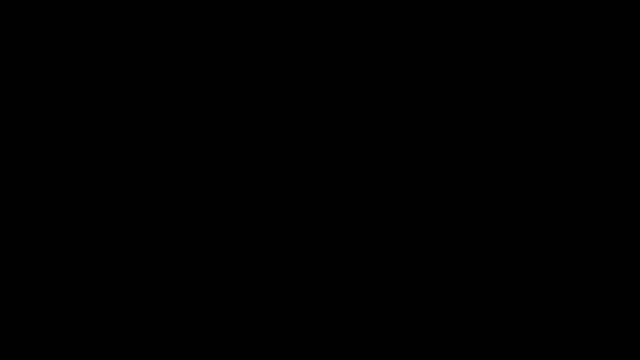

--------------------------------------------------
Shot 140 | Fused: 0.614 | Vis: 0.259 | Txt: 0.157 | Face: False
Time: 393.7s - 399.4s
Transcript: ...


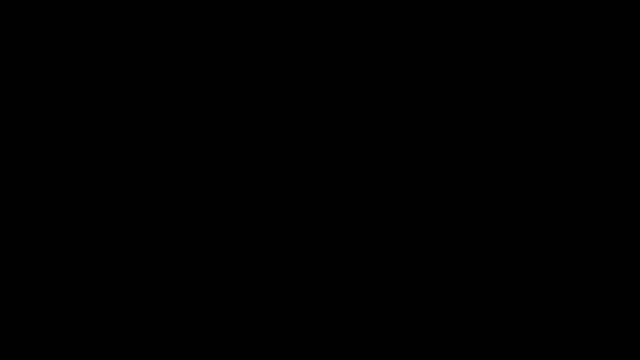

--------------------------------------------------
Shot 19 | Fused: 0.610 | Vis: 0.213 | Txt: 0.233 | Face: False
Time: 57.0s - 57.9s
Transcript: And camera charger....


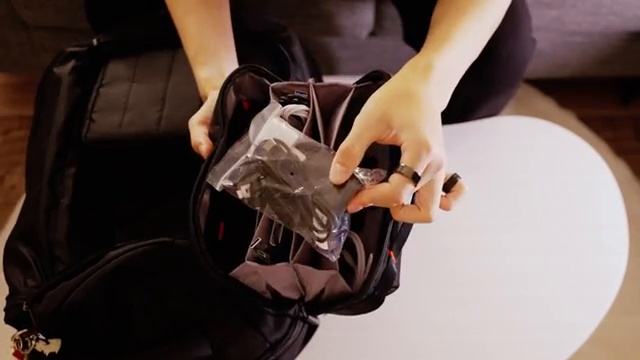

--------------------------------------------------

--- CLUSTER EXPANSION (Cluster 0) ---
Found 3 more shots like this visually:


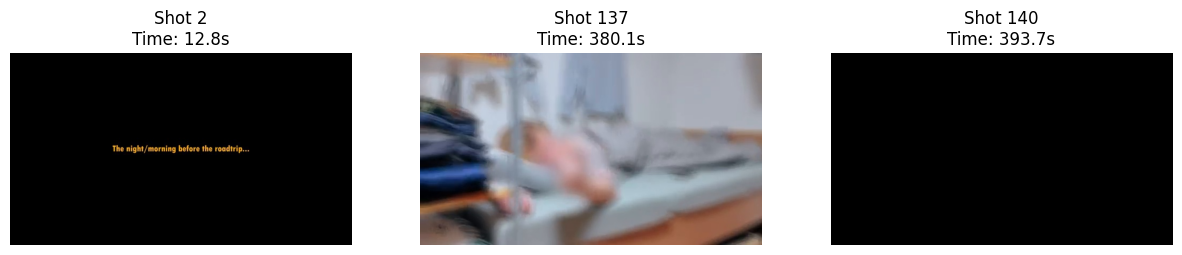

In [ ]:
search_tempo_cascade("phone screen")